In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from outofplane import isOutOfPlane

In [12]:
def generate_webgazer_dataframe(df):
    df1 = df[df["trial_type"] == "html-button-response"]
    df_webgazer = df1[~df1["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [4]:
#Use this version for data from datapruebas
def generate_webgazer_dataframe(df):
    df1 = df[df["trial_type"] == "html-keyboard-response"]
    df_webgazer = df1[~df1["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        json_data = df_webgazer["webgazer_data"].iloc[row].replaceAll("'", "\"")
        data_list = json.loads(json_data)
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [5]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "dataframe_rot" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/dataframe_rot_1.csv


AttributeError: 'str' object has no attribute 'replaceAll'

In [18]:
df_webgazer["isRotated"] = df_webgazer["importantKeypoints"].map(
    lambda x: isOutOfPlane(x)
)

# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isRotated
0,0,0,0,"{'noseX': 313.59, 'noseY': 287.72, 'topY': 209...",79.56,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True..."
1,0,0,41,"{'noseX': 313.54, 'noseY': 287.67, 'topY': 209...",80.60,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True..."
2,0,0,75,"{'noseX': 313.6, 'noseY': 287.79, 'topY': 209....",79.54,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True..."
3,0,0,109,"{'noseX': 313.58, 'noseY': 287.69, 'topY': 209...",80.08,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True..."
4,0,0,143,"{'noseX': 313.53, 'noseY': 287.73, 'topY': 209...",81.08,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True..."
...,...,...,...,...,...,...,...,...,...
16,0,0,547,"{'noseX': 272.67, 'noseY': 274.51, 'topY': 138...",42.94,8,5,data/dataframe_rot_4.csv,"[False, False, False, False, True, True, True,..."
17,0,0,583,"{'noseX': 272.76, 'noseY': 274.48, 'topY': 138...",43.69,8,5,data/dataframe_rot_4.csv,"[False, False, False, False, True, True, True,..."
18,0,0,615,"{'noseX': 272.56, 'noseY': 274.1, 'topY': 138....",42.93,8,5,data/dataframe_rot_4.csv,"[False, False, False, False, True, True, True,..."
19,0,0,648,"{'noseX': 272.68, 'noseY': 273.61, 'topY': 139...",43.00,8,5,data/dataframe_rot_4.csv,"[False, False, False, False, True, True, True,..."


In [19]:
df_webgazer["Rotation_threshold"] = df_webgazer["isRotated"].apply(lambda x: int(x[0]==True))
df_webgazer["Rotation_threshold1"] = df_webgazer["isRotated"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Rotation_threshold2"] = df_webgazer["isRotated"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Rotation_threshold3"] = df_webgazer["isRotated"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Rotation_threshold4"] = df_webgazer["isRotated"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Rotation_threshold5"] = df_webgazer["isRotated"].apply(lambda x: int(x[5]==True)+5)
df_webgazer["Rotation_threshold6"] = df_webgazer["isRotated"].apply(lambda x: int(x[6]==True)+6)
df_webgazer["Rotation_threshold7"] = df_webgazer["isRotated"].apply(lambda x: int(x[7]==True)+7)

In [20]:
df_webgazer.head()

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isRotated,Rotation_threshold,Rotation_threshold1,Rotation_threshold2,Rotation_threshold3,Rotation_threshold4,Rotation_threshold5,Rotation_threshold6,Rotation_threshold7
0,0,0,0,"{'noseX': 313.59, 'noseY': 287.72, 'topY': 209...",79.56,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True...",0,1,2,3,4,6,7,8
1,0,0,41,"{'noseX': 313.54, 'noseY': 287.67, 'topY': 209...",80.60,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True...",0,1,2,3,4,6,7,8
2,0,0,75,"{'noseX': 313.6, 'noseY': 287.79, 'topY': 209....",79.54,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True...",0,1,2,3,4,6,7,8
3,0,0,109,"{'noseX': 313.58, 'noseY': 287.69, 'topY': 209...",80.08,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True...",0,1,2,3,4,6,7,8
4,0,0,143,"{'noseX': 313.53, 'noseY': 287.73, 'topY': 209...",81.08,1,0,data/dataframe_rot_1.csv,"[False, False, False, False, False, True, True...",0,1,2,3,4,6,7,8


/var/folders/bc/dx7gzw5x0d9_snwy574lpzc40000gn/T/ipykernel_1310/3623795091.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


<Figure size 1400x800 with 0 Axes>

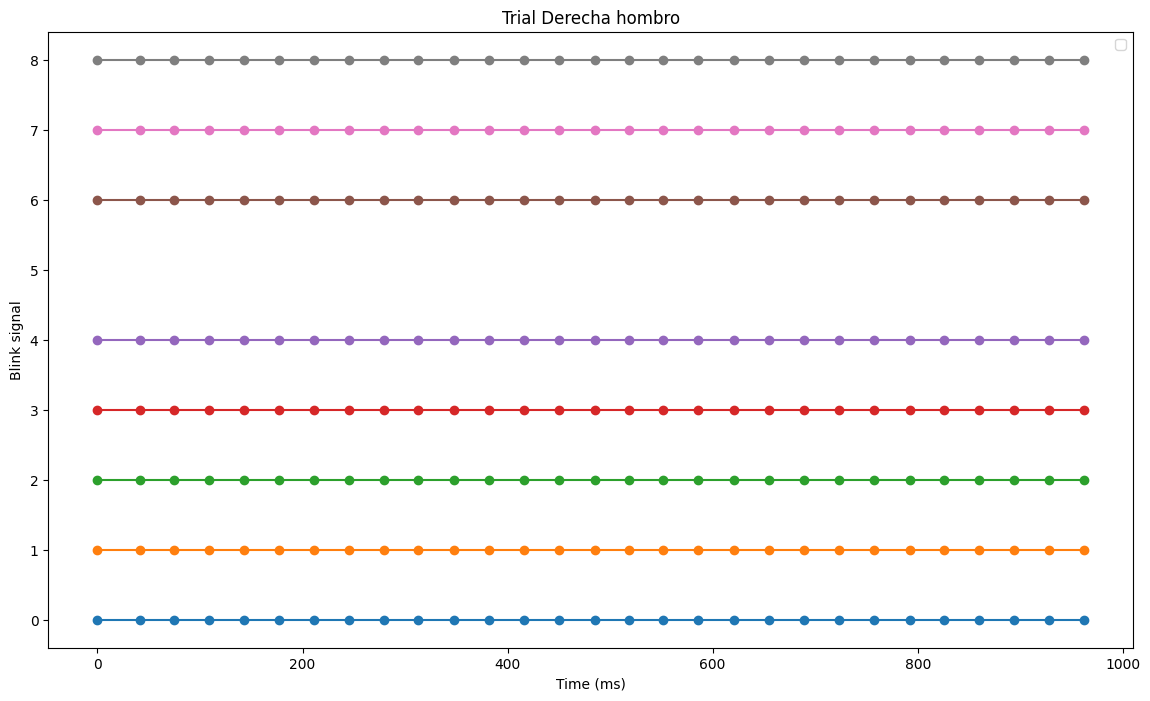

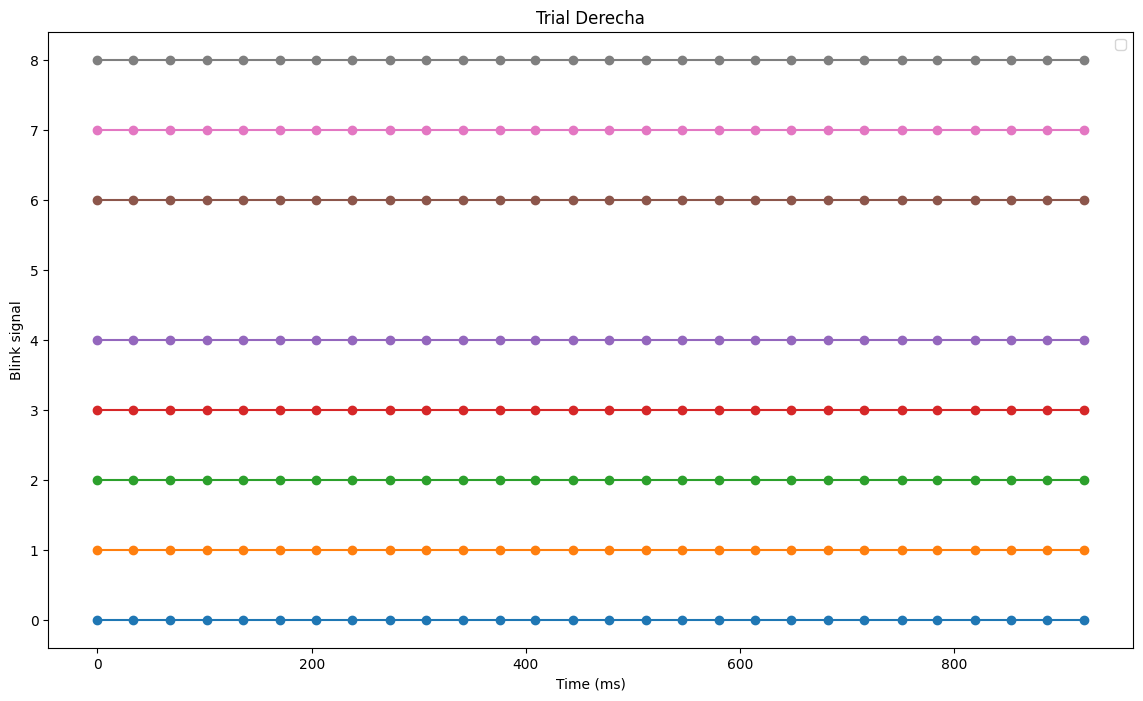

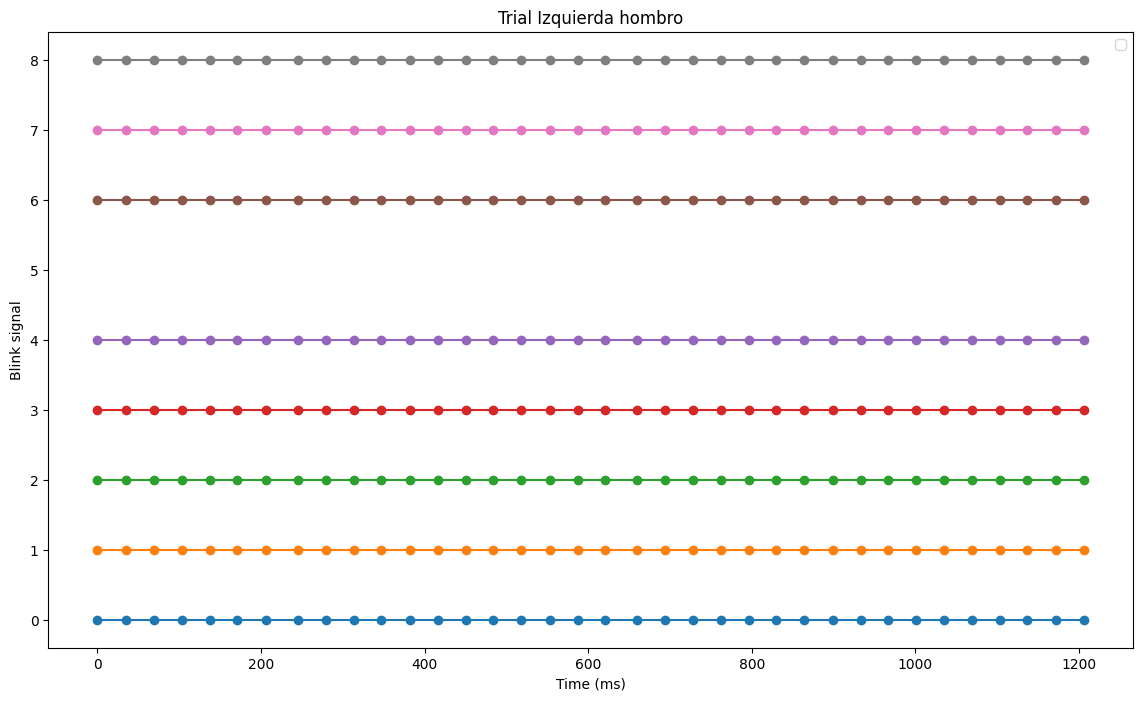

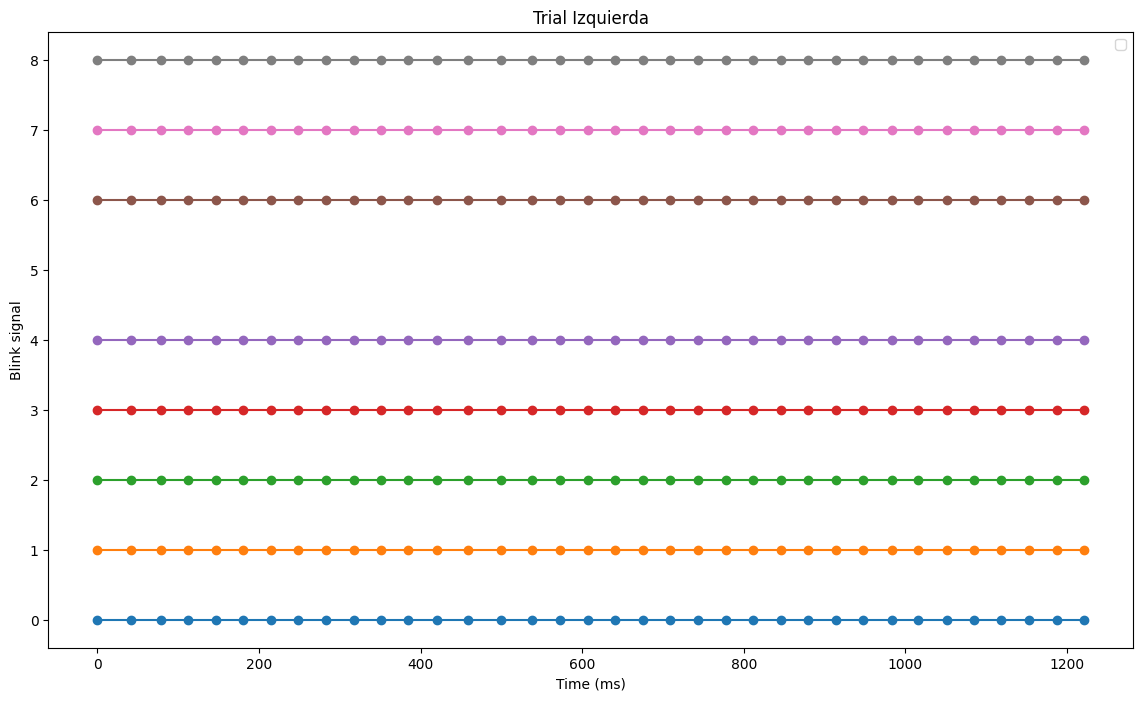

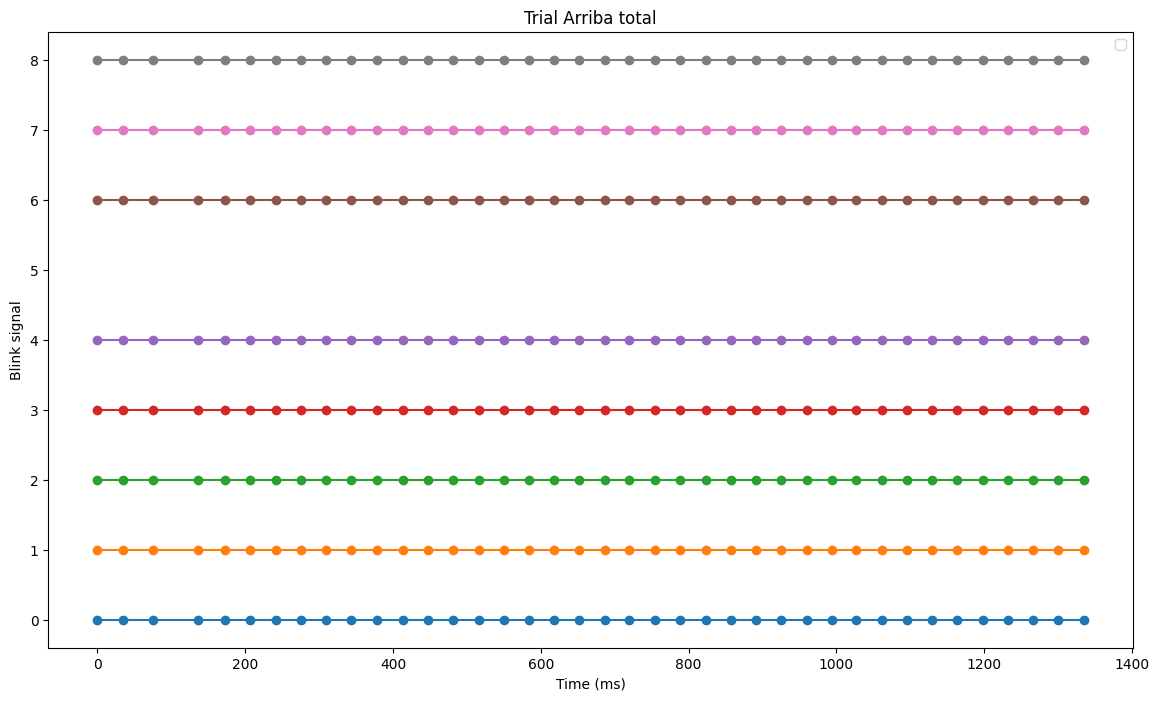

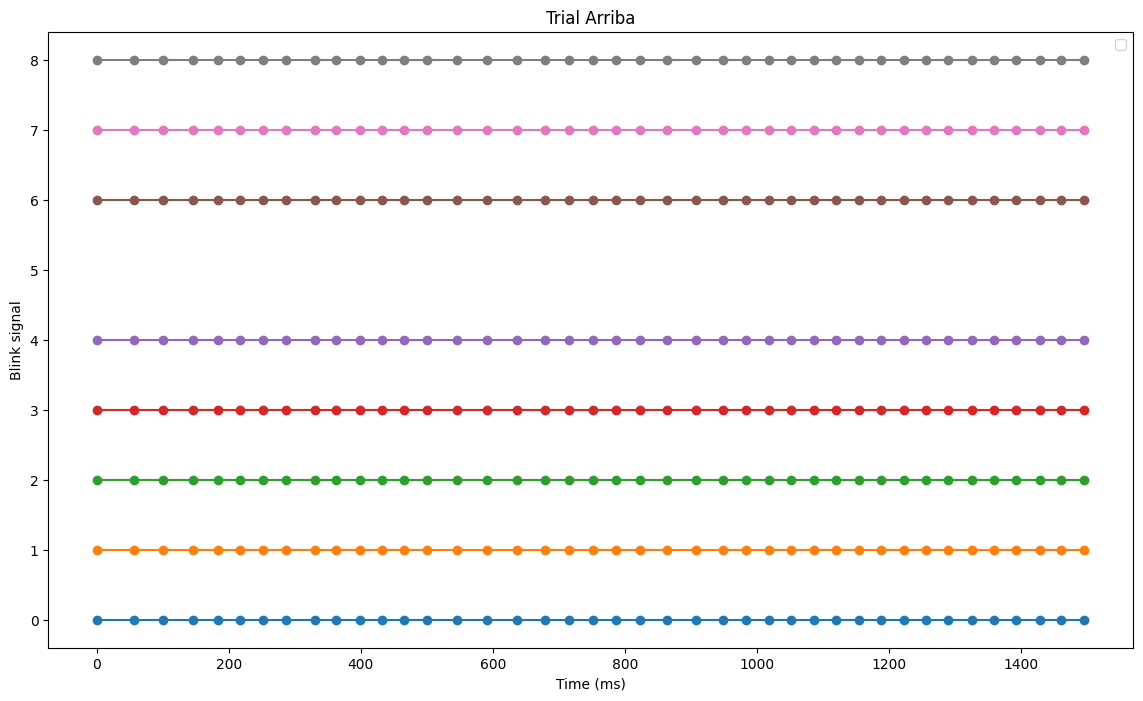

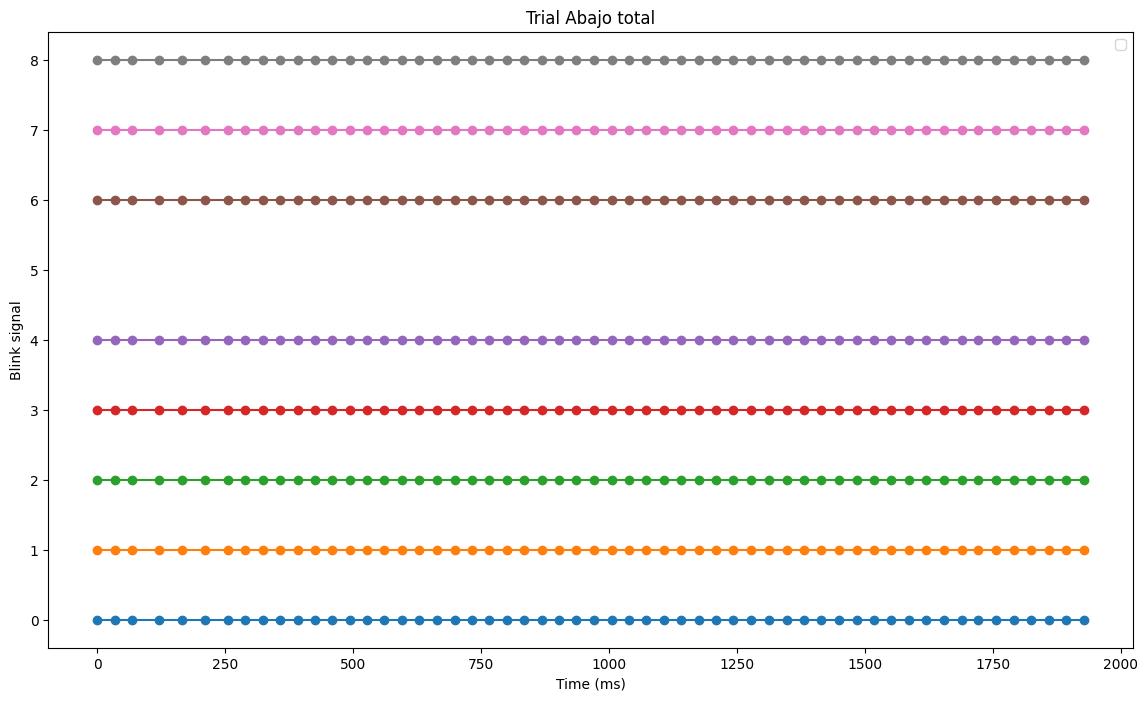

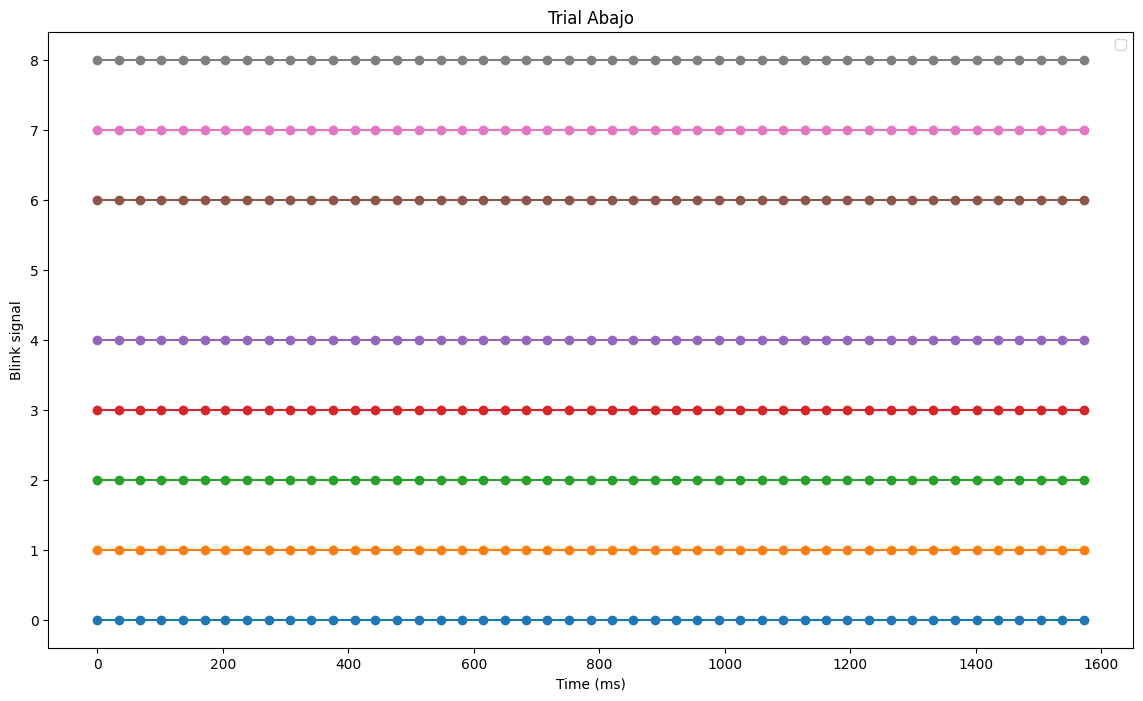

In [28]:
titles = ["Trial Derecha hombro",
          "Trial Derecha",
          "Trial Izquierda hombro",
          "Trial Izquierda",
          "Trial Arriba total",
          "Trial Arriba",
          "Trial Abajo total",
          "Trial Abajo"]

# Initialize the plot
plt.figure(figsize=(14, 8))

df_to_plot = df_webgazer[df_webgazer["experiment"]==0]

#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Rotation_threshold", legend=False)
#df_webgazer[df_webgazer["trial"]==1].plot(x="t", y="Rotation_threshold1", legend=False)
for x in range(8):
  plt.figure(figsize=(14, 8))
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold1)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold2)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold3)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold4)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold5)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold6)
  plt.plot(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold7)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold1)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold2)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold3)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold4)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold5)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold6)
  plt.scatter(df_to_plot[df_to_plot["trial"]==x+1].t ,df_to_plot[df_to_plot["trial"]==x+1].Rotation_threshold7)
  plt.title(titles[x])
  plt.xlabel("Time (ms)")
  plt.ylabel("Blink signal")
  plt.legend(loc="upper right")
  plt.show()




# Plot the blink data using different colors for each type

# Add labels and legend
#plt.title("Blink Scatter Plot")
#plt.xlabel("Time (ms)")
#plt.ylabel("Trial")
#plt.legend(loc="upper right")

# Show plot
#plt.show()


In [10]:
df_webgazer['Rotation_threshold3'][df_webgazer['Rotation_threshold3'].diff()>0].shape

(186,)

In [8]:
df_webgazer["Rotation_threshold0_diff"] = (df_webgazer['Rotation_threshold'].shift(1)+1 == df_webgazer['Rotation_threshold'])
df_webgazer["Rotation_threshold1_diff"] = (df_webgazer['Rotation_threshold1'].shift(1)+1 == df_webgazer['Rotation_threshold1'])
df_webgazer["Rotation_threshold2_diff"] = (df_webgazer['Rotation_threshold2'].shift(1)+1 == df_webgazer['Rotation_threshold2'])
df_webgazer["Rotation_threshold3_diff"] = (df_webgazer['Rotation_threshold3'].shift(1)+1 == df_webgazer['Rotation_threshold3'])
df_webgazer["Rotation_threshold4_diff"] = (df_webgazer['Rotation_threshold4'].shift(1)+1 == df_webgazer['Rotation_threshold4'])
df_webgazer["Rotation_threshold5_diff"] = (df_webgazer['Rotation_threshold5'].shift(1)+1 == df_webgazer['Rotation_threshold5'])
df_webgazer["Rotation_threshold6_diff"] = (df_webgazer['Rotation_threshold6'].shift(1)+1 == df_webgazer['Rotation_threshold6'])
df_webgazer["Rotation_threshold7_diff"] = (df_webgazer['Rotation_threshold7'].shift(1)+1 == df_webgazer['Rotation_threshold7'])

results = []
for x in range(0,8):
    tmp_result = df_webgazer.groupby('trial')['Rotation_threshold' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,trial,Rotation_threshold0_diff,trial,Rotation_threshold1_diff,trial,Rotation_threshold2_diff,trial,Rotation_threshold3_diff,trial,Rotation_threshold4_diff,trial,Rotation_threshold5_diff,trial,Rotation_threshold6_diff,trial,Rotation_threshold7_diff
0,1,13,1,12,1,12,1,13,1,13,1,23,1,30,1,27
1,2,10,2,9,2,9,2,9,2,9,2,26,2,20,2,23
2,3,14,3,14,3,16,3,15,3,17,3,19,3,20,3,30
3,4,16,4,11,4,12,4,10,4,10,4,12,4,11,4,31
4,5,1,5,10,5,33,5,25,5,20,5,18,5,20,5,23
5,6,0,6,0,6,0,6,2,6,4,6,11,6,13,6,59
6,7,0,7,10,7,18,7,13,7,15,7,15,7,14,7,14
7,8,0,8,0,8,4,8,13,8,10,8,18,8,16,8,10


In [12]:
results = []
for x in range(0,8):
    tmp_result = df_webgazer[df_webgazer['trial']==3].groupby('file_name')['Rotation_threshold' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

,file_name,Rotation_threshold0_diff,file_name,Rotation_threshold1_diff,file_name,Rotation_threshold2_diff,file_name,Rotation_threshold3_diff,file_name,Rotation_threshold4_diff,file_name,Rotation_threshold5_diff,file_name,Rotation_threshold6_diff,file_name,Rotation_threshold7_diff
0,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,1,data/rotation-experiment-10.csv,4,data/rotation-experiment-10.csv,2
1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,1,data/rotation-experiment-11.csv,3,data/rotation-experiment-11.csv,5
2,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,1,data/rotation-experiment-12.csv,7,data/rotation-experiment-12.csv,5,data/rotation-experiment-12.csv,1
3,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,1,data/rotation-experiment-13.csv,2,data/rotation-experiment-13.csv,0,data/rotation-experiment-13.csv,0
4,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,0,data/rotation-experiment-14.csv,8,data/rotation-experiment-14.csv,7
5,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0,data/rotation-experiment-15.csv,0
6,data/rotation-experiment-5.csv,2,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,1,data/rotation-experiment-5.csv,0
7,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,1,data/rotation-experiment-6.csv,0,data/rotation-experiment-6.csv,0,data/rotation-experiment-6.csv,0
8,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,1,data/rotation-experiment-7.csv,0,data/rotation-experiment-7.csv,0,data/rotation-experiment-7.csv,0
9,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,1,data/rotation-experiment-8.csv,7,data/rotation-experiment-8.csv,0,data/rotation-experiment-8.csv,0


In [13]:
df_webgazer.groupby('trial')['Rotation_threshold6_diff'].sum().reset_index()


,trial,Rotation_threshold6_diff
0,1,146
1,2,26
2,3,23
3,4,30
4,5,31
5,6,24
6,7,61
7,8,14
8,9,10
